## Part 1: Solving a wave problem with sparse matrices

In this part of the assignment, we want to compute the solution to the following (time-harmonic) wave problem:

$$
\begin{aligned}
\frac{d^2u}{dx^2} + k^2u &= 0 \quad \text{in } (0,1), \\
u &= 0 \quad \text{if } x=0, \\
u &= 1 \quad \text{if } x=1,
\end{aligned}
$$

with wavenumber $k = \frac{29\pi}{2}$.

In this part, we will approximately solving this problem using the method of finite differences.
We do this by taking an evenly spaced values $x_0=0, x_1, x_2, ..., x_N=1$ and approximating the value of $u$ for each value: we will call these approximations $u_i$.
To compute these approximations, we use the approximation:

$$
\frac{d^2u_i}{dx^2} \approx \frac{u_{i-1} - 2u_i + u_{i+1}}{h^2}
$$

where $h = 1/N$.

With a bit of algebra, we see that the wave problem can be written as

$$
(2 - h^2k^2)u_i - u_{i-1} - u_{i+1} = 0
$$

if $x_i$ is not 0 or 1, and

$$
\begin{cases}
u_i = 0 & \text{if } x_i = 0, \\
u_i = 1 & \text{if } x_i = 1.
\end{cases}
$$

This information can be used to re-write the problem as the matrix-vector problem $A\mathbf{u} = \mathbf{f}$, where $A$ is a known matrix, $\mathbf{f}$ is a known vector, and $\mathbf{u}$ is an unknown vector that we want to compute.
The entries of $\mathbf{f}$ and $\mathbf{u}$ are given by

$$
[\mathbf{u}]_i = u_i, \quad [\mathbf{f}]_i =
\begin{cases}
1 & \text{if } i = N, \\
0 & \text{otherwise.}
\end{cases}
$$

The rows of $A$ are given by

$$
[A]_{i,j} =
\begin{cases}
1 & \text{if } i = j, \\
0 & \text{otherwise,}
\end{cases}
$$

if $i = 0$ or $i = N$; and

$$
[A]_{i,j} =
\begin{cases}
2 - h^2k^2 & \text{if } j = i, \\
-1 & \text{if } j = i+1, \\
-1 & \text{if } j = i-1. \\
0 & \text{otherwise}
\end{cases}
$$

Write a Python function that takes N as an input and returns the matrix A and vector f. You should use an appropriate sparse storage format for the matrix A.

The function scipy.sparse.linalg.spsolve can be used to solve a sparse matrix-vector problem. Use this to compute the approximate solution for your problem for N=10, N=100, and N=1000. Use matplotlib (or any other plotting library) to plot the solutions for these three values of N.

Briefly (1-2 sentences) comment on your plots: How different are they from each other? Which do you expect to be closest to the actual solution of the wave problem?

This wave problem was carefully chosen so that its exact solution is known: this solution is 𝑢exact(𝑥)=sin(𝑘𝑥)
. (You can check this by differentiating this twice and substituting, but you do not need to do this part of this assignment.)

A possible approximate measure of the error in your solution can be found by computing

$\max_i |u_i - u_{\text{exact}}(x_i)|$

Compute this error for a range of values for 𝑁
 of your choice, for the method you wrote above. On axes that both use log scales, plot 𝑁
 against the error in your solution. You should pick a range of values for 𝑁
 so that this plot will give you useful information about the methods.

For the same values of 𝑁
, measure the time taken to compute your approximation for your function. On axes that both use log scales, plot 𝑁
 against the time taken to compute a solution.

We now want to compute an approximate solution where the error measure is  $10^{-8}$
 or less. By looking at your plots, pick a value of 𝑁
 that you would expect to give error of $10^{-8}$
 or less. Briefly (1-2 sentences) explain how you picked your value of 𝑁
 and predict how long the computation will take.

Compute the approximate solution with your value of 𝑁
. Measure the time taken and the error, and briefly (1-2 sentences) comment on how these compare to your predictions. Your error may turn out to be higher than $10^{-8}$
 for your value of 𝑁
: if so, you can still get full marks for commenting on why your prediction was not correct. Depending on your implementation and your prediction, a valid conclusion in the section could be “My value of 𝑁
 is too large for it to be feasible to complete this computation in a reasonable amount of time / without running out of memory”.





In [ ]:
#Input modules
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

from scipy.sparse import diags, csr_matrix
from scipy.sparse.linalg import spsolve

from numba import njit, prange

import time

In [ ]:
# Make discrete wave problem solver for N points

def wave_solver(N):
    '''
    Constructs the matrix A and vector f for the system Au = f,
    where u is the solution to the wave equation between 0 and 1.

    Input:
    Args:
        N: The number of discrete points.

    Returns:
        A: The coefficient matrix.
        f: The right-hand side vector.
        x: The array of discrete x values.
    '''
    # Initialise x and constants
    x = np.linspace(0, 1, N+1)
    h = 1 / N
    k = 29 * np.pi / 2

    # Create RHS vector f
    f = np.zeros(N+1)
    f[N] = 1

    # Create sparse matrix A
    diagonals = [2 - h**2 * k**2, -1, -1]
    offsets = [0, -1, 1]
    A = diags(diagonals, offsets, shape=(N+1, N+1)).tocsr()

    # Assert boundary conditions
    A[0, 0] = 1
    A[N, N] = 1

    A[0, 1] = 0
    A[N, N-1] = 0

    return A, f, x


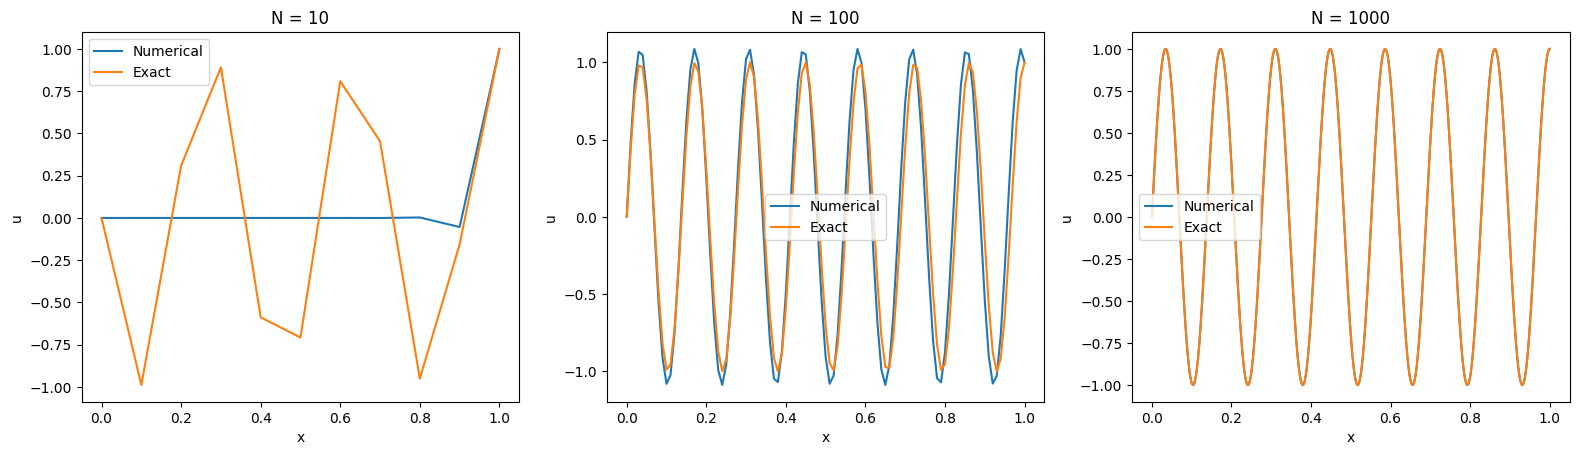

In [ ]:
# Solve and plot for N = 10,100 and 1000
# Where Au = f

N_list = [10, 100, 1000]
fig, axes = plt.subplots(1, len(N_list), figsize=(6.4*len(N_list), 4.8))
k = 29*np.pi/2

for i, N in enumerate(N_list):
    A, f, x = wave_solver(N)
    u = spsolve(A, f)
    #u = u / np.max(np.abs(u))
    u_exact = np.sin(k*x)
    axes[i].plot(x, u)
    axes[i].plot(x, u_exact)
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('u')
    axes[i].legend(['Numerical', 'Exact'])
    axes[i].set_title('N = ' + str(N))

## Comments on plots

For N = 10 the approimation strrugles to converge in the function only managed to adapt to the boundary. For N = 100 it converges to a sin(kx) However, its amplitude is slightly more than one with spiked turning points, furthermore, it is out of slightly phase. As expected due to the higer number of vertices N=1000 has the closest approximation with little to no visual differences between the actual plot and the approximation.

In [ ]:
# Record error and time taken for range of N
N_list = np.arange(10,5000,200,dtype = int)
error_list = []
time_list = []
for N in N_list:
    start = time.perf_counter()
    A, f, x = wave_solver(N)
    u = spsolve(A, f)
    end = time.perf_counter()
    u_exact = np.sin(k*x)
    error = np.max(np.abs(u - u_exact))
    error_list.append(error)
    time_list.append(end - start)

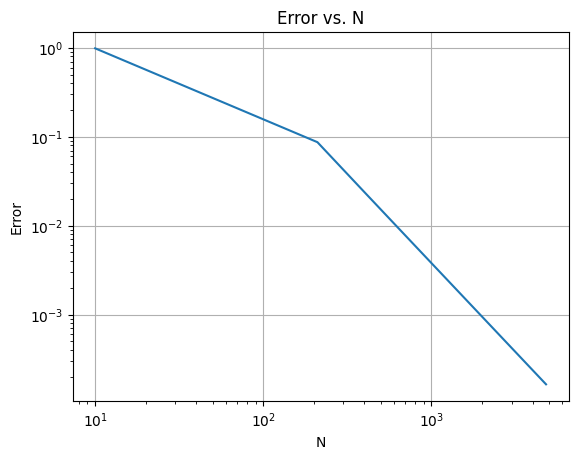

In [ ]:
# Plot Errors
plt.plot(N_list, error_list)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('N')
plt.ylabel('Error')
plt.grid(True)
plt.title('Error vs. N')
plt.show()

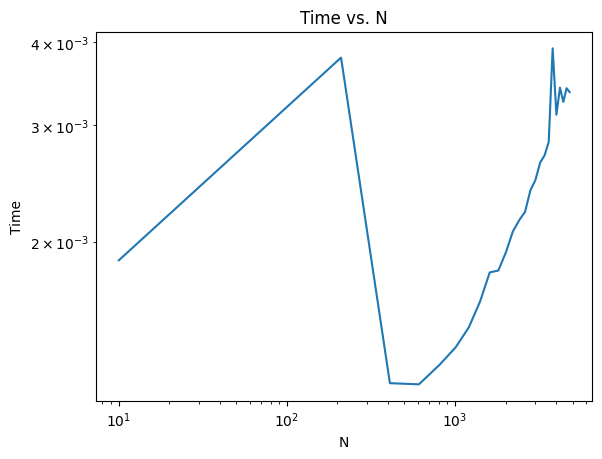

In [ ]:
# Plot times
plt.plot(N_list, time_list)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('N')
plt.ylabel('Time')
plt.title('Time vs. N')
plt.show()

## Make predication from error plots for N will give $10^{-8}$ and how long it will take

Based on the the previous log-log graph we can be a linear downward trend in time, from this we can extrapolate that from N = $5*10^3$ getting an error of $10^{-4}$ we expect to reach $10^{-8}$ for N = $6*10^{5}$ Time is much harder to make a prediction for to its unruly nature however, keeping a linear pattern from N = $10^3$ we can estimate a runtime of $2*10^{-1}$s.

In [ ]:
# Calculate error for list of predicted N
N_list_p = np.arange(10,600000,10000,dtype = int)
error_list_p = []
time_list_p = []

for N in N_list_p:
    start = time.perf_counter()
    A, f, x = wave_solver(N)
    u = spsolve(A, f)
    end = time.perf_counter()
    u_exact = np.sin(k*x)
    error = np.max(np.abs(u - u_exact))
    error_list_p.append(error)
    time_list_p.append(end - start)

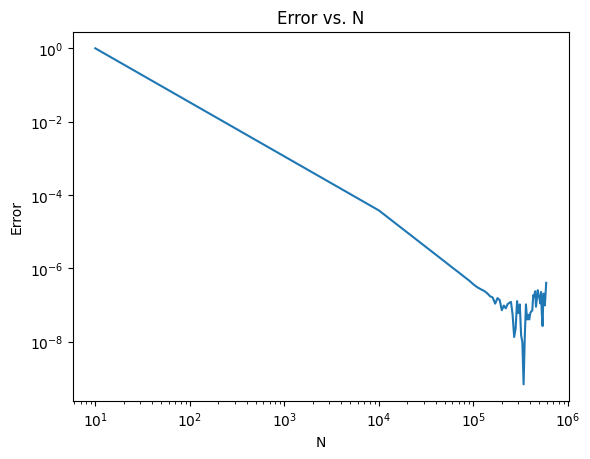

In [ ]:
# Plot error against N
plt.plot(N_list_p, error_list_p)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('N')
plt.ylabel('Error')
plt.title('Error vs. N')
plt.show()

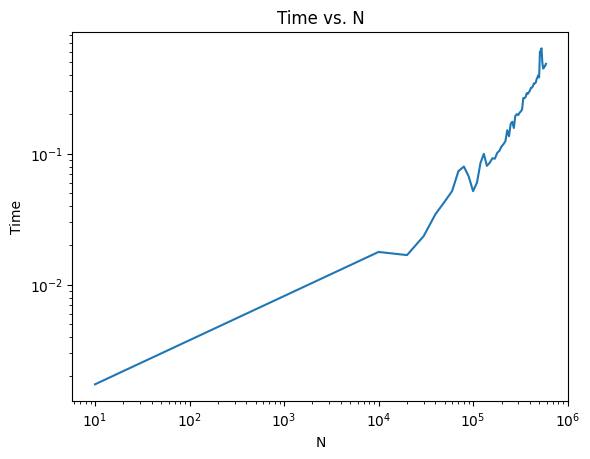

In [ ]:
# Plot N against time
plt.plot(N_list_p, time_list_p)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('N')
plt.ylabel('Time')
plt.title('Time vs. N')
plt.show()

## Comments on prediction

Overall the predictions werre mostly accurate, time being a bit higher than expected, further error lost linearity as it tried to converge into the function, although N = $6*10^{5}$ was in the correct area.

## Part 2: Solving the heat equation with GPU acceleration

In this part of the assignment, we want to solve the heat equation

$$
\begin{aligned}
\frac{du}{dt} &= \frac{1}{11000} \frac{d^2u}{dx^2} \quad \text{for } x \in (0,1), \\
u(x,0) &= 0, \quad \text{if } x \neq 0 \text{ and } x \neq 1 \\
u(0,t) &= 10, \\
u(1,t) &= 10.
\end{aligned}
$$

This represents a rod that starts at 0 and is heated to 10 at both ends.

Again, we will approximately solve this by taking an evenly spaced values $x_0=0, x_1, x_2, ..., x_N=1$. Additionally, we will take a set of evenly spaced times $t_0=0, t_1=h, t_2=2h, t_3=3h,...$, where $h=1/N$. We will write $u^{(j)}_i$ for the approximate value of $u$ at point $x_i$ and time $t_j$ (i.e. $u^{(j)}_i \approx u(x_i, t_j)$).

Approximating both derivatives (similar to what we did in part 1), and doing some algebra, we can rewrite the heat equation as

$$
u^{(j+1)}_i = u^{(j)}_i + \frac{u^{(j)}_{i-1} - 2u^{(j)}_i + u^{(j)}_{i+1}}{1000h},
$$

$$
u^{(0)}_i = 0,
$$

$$
u^{(j)}_0 = 10,
$$

$$
u^{(j)}_N = 10.
$$

This leads us to an iterative method for solving this problem: first, at $t=0$, we set

$$
u^{(0)}_i =
\begin{cases}
10 & \text{if } i=0 \text{ or } i=N, \\
0 & \text{otherwise;}
\end{cases}
$$

then for all later values of time, we set

$$
u^{(j+1)}_i =
\begin{cases}
10 & \text{if } i=0 \text{ or } i=N, \\
u^{(j)}_i + \frac{u^{(j)}_{i-1} - 2u^{(j)}_i + u^{(j)}_{i+1}}{1000h}  & \text{otherwise.}
\end{cases}
$$

Implement this iterative scheme in Python. You should implement this as a function that takes N as an input.

Using a sensible value of 𝑁
, plot the temperature of the rod at 𝑡=1
, 𝑡=2
 and 𝑡=10
. Briefly (1-2 sentences) comment on how you picked a value for 𝑁
.

Use numba.cuda to parallelise your implementation on a GPU. You should think carefully about when data needs to be copied and be careful not to copy data to/from the GPU when not needed.

Use your code to estimate the time at which the temperature of the midpoint of the rod first exceeds a temperature of 9.8. Briefly (2-3 sentences) describe how you estimated this time. You may choose to use a plot or diagram to aid your description, but it is not essential to include a plot.

In [ ]:
# Define discrete heat eqn solver between x = 0 and x = 1

@njit(parallel = True)
def heat_solver(N,t):
    '''
    Returns iterative solution for u(x,t)
    where u is the solution to the heat eqn.

      Input:
   Args:
      N: The number of discrete points.

  Returns:
      u: Heat equation solution.
      t: The array of discrete time vaules
      x: The array of discrete x values.
    '''
    x = np.linspace(0, 1, N+1)
    h = 1/N # timestep for total time t
    t_arr = np.arange(0,t+h,h)

    # Create u(x,t) array
    u = np.zeros((N+1, len(t_arr)))

    # Assert boundary conditions
    u[0,:] = 10
    u[N,:] = 10

    # Iterate through time
    for j in prange(len(t_arr)-1):
        for i in range(1,N):
          u[i,j+1] = u[i,j] + (u[i-1,j] - 2*u[i,j] + u[i+1,j])/(1000*h)


    return u, x, t_arr


In [ ]:
# Solve eqn for given N up to given t
N = 200
t = 400
u, x, t = heat_solver(N,t)

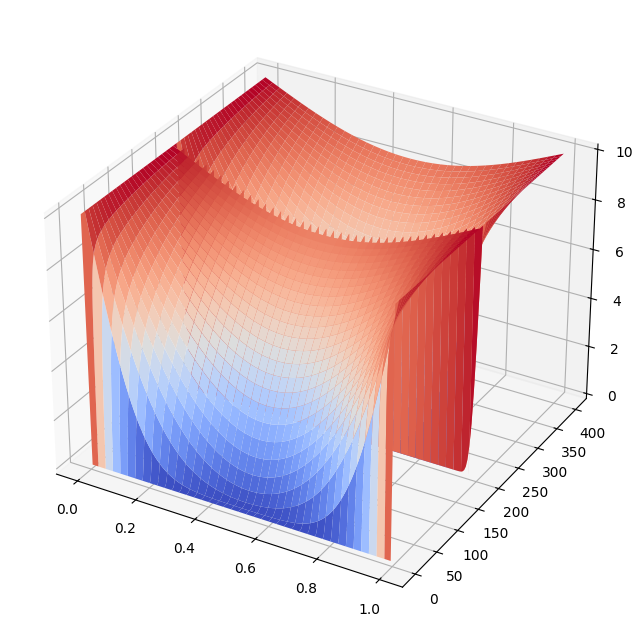

In [ ]:
# Plot 3D contour map
# Odd dip which forms around middle of input t.

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(projection='3d')
X, T = np.meshgrid(x, t)
surf = ax.plot_surface(X, T, np.transpose(u), antialiased=True, cmap=cm.coolwarm)
plt.show()

Text(0, 0.5, 'u')

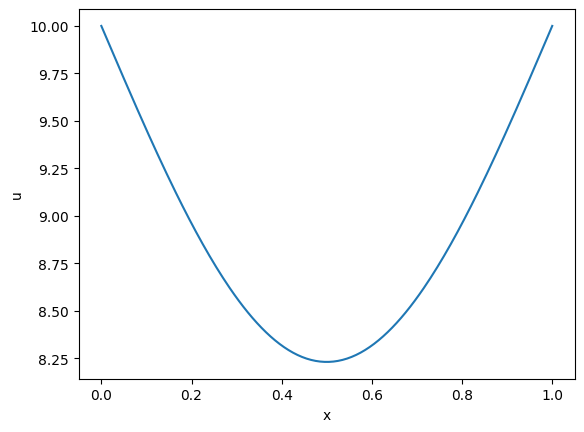

In [ ]:
# Plot a 2d slice of u against x for time = t
# Frame = 10 referns to t_10 step or t = 10*h
time = 200
frame = int(time*N)
plt.plot(x, u[:,frame])
plt.xlabel('x')
plt.ylabel('u')

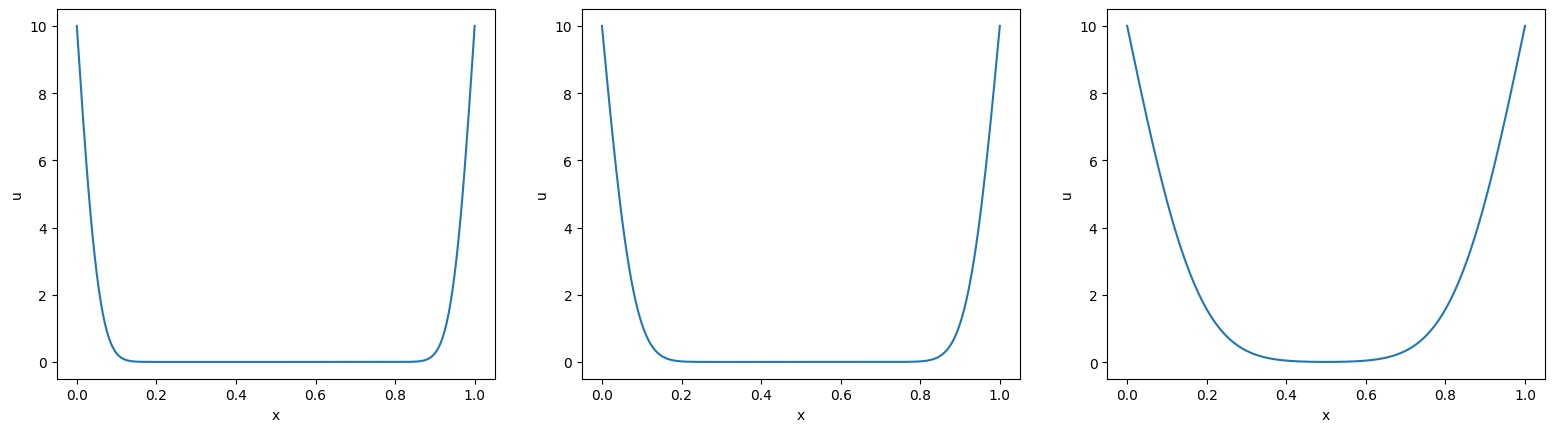

In [ ]:
# Plot for t = 1, 2 and 10
time_list = [1,2,10]
fig, axes = plt.subplots(1, len(time_list), figsize=(6.4*len(time_list), 4.8))
for i, time in enumerate(time_list):
    frame = int(time*N)
    axes[i].plot(x, u[:,frame])
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('u')


## Chosen N justification

N was chosen to be 200 as it offerd a strong resolution and kept computation times low. N was also chosen to be around 200 as when testing didn't a large enough percentage of the RAM to risk a crash.

In [ ]:
from numba import cuda
cuda.detect()

Found 1 CUDA devices
id 0             b'Tesla T4'                              [SUPPORTED]
                      Compute Capability: 7.5
                           PCI Device ID: 4
                              PCI Bus ID: 0
                                    UUID: GPU-1be0e439-8a1e-78fd-421f-95533600ff5b
                                Watchdog: Disabled
             FP32/FP64 Performance Ratio: 32
Summary:
	1/1 devices are supported


True

In [ ]:
# Speed up with GPU
@cuda.jit
def heat_kernel(u, h, N, j):
    i = cuda.grid(1)
    if 0 < i < N:
        u[i, j+1] = u[i, j] + (u[i-1, j] - 2*u[i, j] + u[i+1, j]) / (1000 * h)

def heat_solver_gpu(N, t):

    assert N % 2 == 1, "N must be odd to ensure a definite center term."
    assert N > 2, "N must be greater than 2 to define a valid grid."

    x = np.linspace(0, 1, N+1)
    h = 1/N
    t_arr = np.arange(0,t+h,h)

    u = np.zeros((N+1, len(t_arr)))
    u[0,:] = 10
    u[N,:] = 10
    d_u = cuda.to_device(u)  # Transfer u to GPU

    # GPU accelerated time loop
    threads_per_block = (32, 32)
    blocks_grid_x = (N + (threads_per_block[0] - 1)) // threads_per_block[0]
    grid_size = (blocks_grid_x,)

    for j in range(len(t_arr)-1):
        heat_kernel[grid_size, threads_per_block](d_u, h, N, j)

    u = d_u.copy_to_host() # Copy back to CPU

    return u, x, t_arr

In [ ]:
# Solve eqn for given N and t
N_2 = 200
t_2 = 1000
u2, x2, t2 = heat_solver_gpu(N_2,t_2)

/usr/local/lib/python3.10/dist-packages/numba/cuda/dispatcher.py:536: NumbaPerformanceWarning: Grid size 7 will likely result in GPU under-utilization due to low occupancy.
  warn(NumbaPerformanceWarning(msg))


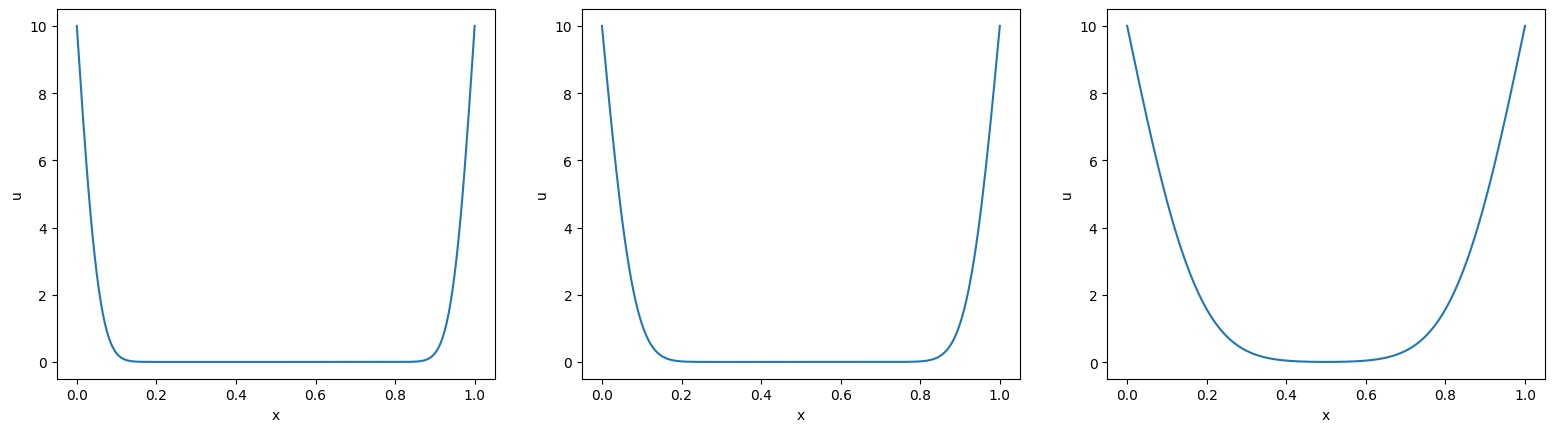

In [ ]:
# Plot for t = 1, 2 and 10
# Compare against first soltuion

time_list = [1,2,10]
fig, axes = plt.subplots(1, len(time_list), figsize=(6.4*len(time_list), 4.8))
for i, time in enumerate(time_list):
    frame = int(time*N_2)
    axes[i].plot(x2, u2[:,frame])
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('u')

In [ ]:
# Estimate time when u for L = 1/2 has u = 9.8
count = 0
for j in u2[int(N_2/2),:]:
    count += 1
    if j > 9.8: # Finds frame when u = 9.8 is croessed
        print(count/N_2) # Converts into time
        break


420.85


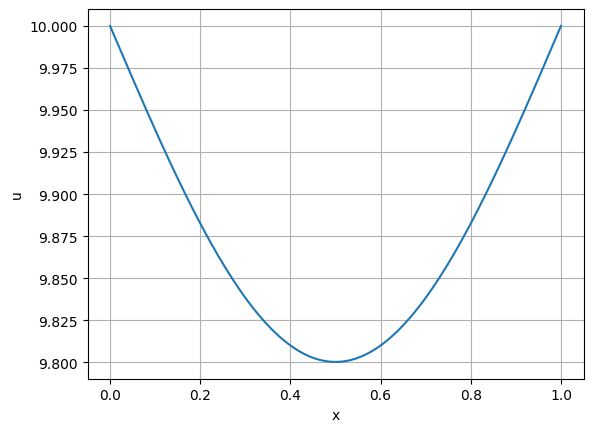

In [ ]:
# Plot u for predicted time
time = 421
frame = int(time*N_2)
plt.plot(x2, u2[:,frame])
plt.xlabel('x')
plt.ylabel('u')
plt.grid(True)

## u = 9.8 estimation

Estimated t when u(1/2,t) > 9.8, by using estimated u(x,t) and iterating over all times and breaking the loop when the threhold was crossed. The time for this was 420.85s, rounding up and plotting gives us the above graph where at x = 1/2, u = 9.8.

In [ ]:
print('Hello')

Hello


**Q1. Worded:**

**Define what is a conservative force in the context of classical mechanics.**

In classical mechanics, a conservative force is a force that does work that is independent of the path taken. This means that the work done by the force in moving an object from point A to point B is the same regardless of the path taken between those two points.  Essentially, the work done depends only on the initial and final positions of the object. This path independence also implies that the work done by the force on a closed loop is zero.

A common example is gravity. Whether you lift an object straight up or take a more convoluted route, the work done against gravity depends only on the change in height.

**For a conservative force F, mathematically define the potential energy.**

For a conservative force F, we can define a potential energy *U*. This potential energy is a function of position and represents the stored energy an object has due to its position in a force field. It's defined as the negative of the work done by the force in moving an object from a reference point to a given point. Mathematically:

*U(r) = - ∫ F • dr*

where:

*  *U(r)* is the potential energy at position *r*
*  The integral symbol (∫) represents the work done by the force over a path
*  *F* is the conservative force
*  *dr* is a small displacement along the path
*  The integral is evaluated from a reference point *r<sub>0</sub>* to the point *r*

**Why is it not possible to define a potential energy for a force which is not conservative?**

Non-conservative forces, like friction,  don't have this path independence. The work done by a non-conservative force *does* depend on the path taken. This makes it impossible to define a unique potential energy function.

Think of pushing a box across a rough floor. The longer the path you push it along, the more work friction does. Since the work done depends on the path, you can't assign a single potential energy value to a given position.


Here’s the solution in a more straightforward, descriptive format:

---

The equation of motion for a damped harmonic oscillator is:  
\[
\frac{d^2x}{dt^2} + b\frac{dx}{dt} + kx = 0
\]  
where \(b\) is the damping coefficient and \(k\) is the spring constant. The behavior of the system depends on the discriminant of the characteristic equation derived from this differential equation:  
\[
\lambda^2 + b\lambda + k = 0
\]  
The discriminant is \(\Delta = b^2 - 4k\), and the nature of the damping depends on its value:

### 1. Overdamping (\(\Delta > 0\), \(b^2 > 4k\))  
Here, the damping is strong, and the system has two distinct real roots (\(\lambda_1, \lambda_2\)) for the characteristic equation. The solution takes the form:  
\[
x(t) = C_1 e^{\lambda_1 t} + C_2 e^{\lambda_2 t}
\]  
The motion is non-oscillatory and purely exponential. The system slowly returns to equilibrium, with no oscillations occurring.

### 2. Critical Damping (\(\Delta = 0\), \(b^2 = 4k\))  
Critical damping occurs when the damping is just sufficient to prevent oscillations but allows the system to return to equilibrium as quickly as possible. There is one repeated real root (\(\lambda = -b/2\)). The solution is:  
\[
x(t) = (C_1 + C_2 t)e^{\lambda t}
\]  
The system decays directly to equilibrium without oscillating, achieving the fastest return among all cases.

### 3. Underdamping (\(\Delta < 0\), \(b^2 < 4k\))  
Here, the damping is weak, leading to complex conjugate roots (\(\lambda = -b/2 \pm i\omega\), where \(\omega = \sqrt{(4k - b^2)/4}\)). The solution is oscillatory with exponentially decaying amplitude:  
\[
x(t) = e^{-\frac{b}{2}t} \left(C_1 \cos(\omega t) + C_2 \sin(\omega t)\right)
\]  
The system oscillates while gradually losing energy due to damping, eventually coming to rest at equilibrium.

---

### Qualitative Summary:
1. **Overdamping:** The system does not oscillate and returns to equilibrium slowly.  
2. **Critical Damping:** The system does not oscillate and returns to equilibrium as fast as possible.  
3. **Underdamping:** The system oscillates with a decaying amplitude, eventually settling at equilibrium.